# Feature Engineering
This series of notebooks help data scientists to forecast multiple time series by building models based on the time-series profiling, i.e identifying similar consumption profiles and building a specific model for each cluster. Profiling is a given input to you, now in this notebook you will learn:

1) How to use mlforecast to add classic time-series features quickly:
   - Calendar features (year, month)
   - Lags (lag-1, lag-2)
   - Rolling statistics (rolling mean + rolling std)

2) How to inspect engineered features:
   - Correlation with y
   - A Pareto-style plot of strongest correlations

3) How to train an XGBoost regressor on those features and visualize feature importance.

# Summary of tasks

Your task in this notebook is to deal with feature engineering, to inspect engineered features and to train an XGBoost model.

Your **goal** is:
- Use mlforecast to create features: year, month, lag1, lag2, rolling means & stds.
- Show correlations vs y and a Pareto of strongest correlations.
- Train an XGBoost model on the engineered table and plot feature importance.


The **Business context** for column meanings (example company that sells compute servers):
- `date`: timestamp for the observation (monthly recommended in this demo)
- `unique_id`: the time series identifier. In our setting: specific product SKU or SKU-region combo
- `Categorical_1`: product type (e.g., 'compute_server', 'private_cloud', etc.)
- `Categorical_2`: geographic region (e.g., 'northwest', 'southwest', ...)
- `Continuous_1`: unit_cost (unit manufacturing or acquisition cost)
- `Continuous_2`: unit_installation_cost (per-unit install cost)
- `y`: the target you want to forecast (e.g., monthly units sold or demand)
- `cluster`: a precomputed cluster label for the series (optional static covariate)
- `profile`: a profile label/segment for the series (optional static covariate)

We will rename those to friendlier names:
    date -> ds   (mlforecast expects 'ds' for the timestamp column)
    unique_id -> unique_id (kept as-is)
    Categorical_1 -> product_type
    Categorical_2 -> region
    Continuous_1 -> unit_cost
    Continuous_2 -> unit_installation_cost
    y -> y
    cluster -> cluster
    profile -> profile

IMPORTANT: In mlforecast, `unique_id` defines the *series*. Any feature you add must respect the series boundary—
it never leaks information across different `unique_id`s.

# Import Required Libraries

In [25]:
# Data elaboration
import pandas as pd
import numpy as np
import datetime as dt
from pathlib import Path

# Plotting
import matplotlib.pyplot as plt
%matplotlib inline

# Nixtla MLForecast
from mlforecast import MLForecast
from mlforecast.lag_transforms import RollingMean, RollingStd

# Model
from xgboost import XGBRegressor

print("✅ All imports successful!")

✅ All imports successful!


# Configuration

Configuration parameters for the time series analysis (previously loaded from config.yaml).

In [26]:
# Time series configuration
date_var = 'WEEK_START_DT'
date_format = '%Y-%m-%d'
y = 'TOTAL_NET_SALES'
unique_id = 'STORE_LOCATION_ID'
frequency = 'W'

# Fabric Lakehouse configuration
LAKEHOUSE_NAME = "ts_forecasting"
INPUT_TABLE = "df_final"
PROFILING_TABLE = "df_profiling_clustering"
OUTPUT_TABLE = "df_features"

root_path = Path.cwd().parent.parent

print("✅ Configuration loaded")
print(f"   date_var: {date_var}")
print(f"   unique_id: {unique_id}")
print(f"   target: {y}")
print(f"   frequency: {frequency}")

✅ Configuration loaded
   date_var: WEEK_START_DT
   unique_id: STORE_LOCATION_ID
   target: TOTAL_NET_SALES
   frequency: W


# Load Data from Lakehouse

Load the profiling/cluster data and the prepared demand data from Fabric Lakehouse tables.

In [27]:
try:
    df_final = spark.table(f"{LAKEHOUSE_NAME}.{INPUT_TABLE}")
    df_final = df_final.toPandas()
except:
    print(f"❌ Error loading data from {LAKEHOUSE_NAME}.{INPUT_TABLE}, loading from local file instead.")
    root_path = Path.cwd().parent.parent
    df_final = pd.read_parquet(f"{root_path}/data/{INPUT_TABLE}.parquet")  # Fallback to local file if Lakehouse load fails

print(f"✅ Loaded {len(df_final)} rows")
print(df_final.head())

❌ Error loading data from ts_forecasting.df_final, loading from local file instead.
✅ Loaded 5150 rows
   STORE_LOCATION_ID WEEK_START_DT  TOTAL_NET_SALES  STORE_SELLING_AREA_SQFT  \
0                  1    2023-04-03    522814.849132                    32653   
1                  1    2023-04-10    620024.491881                    32653   
2                  1    2023-04-17    623209.751040                    32653   
3                  1    2023-04-24    641359.169727                    32653   
4                  1    2023-05-01    615285.571504                    32653   

   NEARBY_COMPETITOR_STORE_COUNT  COMPETITOR_PREMIUM_A_PRESENT  \
0                              2                             0   
1                              2                             0   
2                              2                             0   
3                              2                             0   
4                              2                             0   

   COMPETITOR_DISCO

In [28]:
# Read from Lakehouse table using Spark, then convert to Pandas
try:
    df_profiling_clustering = spark.table(f"{LAKEHOUSE_NAME}.{PROFILING_TABLE}")
    df_profiling_clustering = df_profiling_clustering.toPandas()
except:
    print(f"❌ Error loading data from {LAKEHOUSE_NAME}.{PROFILING_TABLE}, loading from local file instead.")
    root_path = Path.cwd().parent.parent
    df_profiling_clustering = pd.read_parquet(f"{root_path}/data/{PROFILING_TABLE}.parquet")  # Fallback to local file if Lakehouse load fails

print(f"✅ Loaded {len(df_profiling_clustering)} rows")
print(df_profiling_clustering.head())

❌ Error loading data from ts_forecasting.df_profiling_clustering, loading from local file instead.
✅ Loaded 50 rows
   STORE_LOCATION_ID            type    k    low_demand       cv2  \
0                  1  perc_quant_999  104   8940.829821  0.008785   
1                  2  perc_quant_999  104  10578.524016  0.007223   
2                  3  perc_quant_999  104   9873.770989  0.008576   
3                  4  perc_quant_999  104   8020.106804  0.009021   
4                  5  perc_quant_999  104  10277.917446  0.009031   

           adi          sddi  profile_cluster  
0  2655.200064  55517.007000                1  
1  4864.611906  59812.124498                1  
2  2314.251762  65229.710488                1  
3  1777.046773  52434.884734                0  
4  1592.356205  65603.320324                1  


# Merge Datasets

Merge the demand data with profiling and cluster information.

In [30]:
# Merge datasets
df = pd.merge(
    df_final, 
    df_profiling_clustering[[unique_id, 'profile_cluster']], 
    on=unique_id, 
    how='left', 
    validate='m:1'
)
print(f"✅ Merged dataset shape: {df.shape}")
df.head()

✅ Merged dataset shape: (5150, 96)


,STORE_LOCATION_ID,WEEK_START_DT,TOTAL_NET_SALES,STORE_SELLING_AREA_SQFT,NEARBY_COMPETITOR_STORE_COUNT,COMPETITOR_PREMIUM_A_PRESENT,COMPETITOR_DISCOUNT_A_PRESENT,COMPETITOR_WAREHOUSE_A_PRESENT,COMPETITOR_PREMIUM_B_PRESENT,COMPETITOR_DISCOUNT_B_PRESENT,...,HOLIDAY_BOXING_DAY,HOLIDAY_AFTER_THANKSGIVING,EVENT_VALENTINES,EVENT_MOTHERS_DAY,EVENT_FATHERS_DAY,EVENT_HALLOWEEN,EVENT_BLACK_FRIDAY,EVENT_CHINESE_NEW_YEAR,EVENT_STANLEY_CUP_FINAL,profile_cluster
0,1,2023-04-03,522814.849132,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,1
1,1,2023-04-10,620024.491881,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,1
2,1,2023-04-17,623209.751040,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,1
3,1,2023-04-24,641359.169727,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,1
4,1,2023-05-01,615285.571504,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,1


# Standardize Column Names

Rename columns to match mlforecast expectations and ensure consistent naming.

In [31]:
# Standardize column names
rename_map = {
    date_var: "ds",  # mlforecast expects time column as 'ds'
}
df = df.rename(columns=rename_map)

print("Adjusting date_var to ds")
date_var = 'ds'
df.head()

Adjusting date_var to ds


,STORE_LOCATION_ID,ds,TOTAL_NET_SALES,STORE_SELLING_AREA_SQFT,NEARBY_COMPETITOR_STORE_COUNT,COMPETITOR_PREMIUM_A_PRESENT,COMPETITOR_DISCOUNT_A_PRESENT,COMPETITOR_WAREHOUSE_A_PRESENT,COMPETITOR_PREMIUM_B_PRESENT,COMPETITOR_DISCOUNT_B_PRESENT,...,HOLIDAY_BOXING_DAY,HOLIDAY_AFTER_THANKSGIVING,EVENT_VALENTINES,EVENT_MOTHERS_DAY,EVENT_FATHERS_DAY,EVENT_HALLOWEEN,EVENT_BLACK_FRIDAY,EVENT_CHINESE_NEW_YEAR,EVENT_STANLEY_CUP_FINAL,profile_cluster
0,1,2023-04-03,522814.849132,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,1
1,1,2023-04-10,620024.491881,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,1
2,1,2023-04-17,623209.751040,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,1
3,1,2023-04-24,641359.169727,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,1
4,1,2023-05-01,615285.571504,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,1


# Ensure Proper Data Types

### Date features

In [32]:
df['ds'] = pd.to_datetime(df['ds'])
df['year'] = df['ds'].dt.year
df['month'] = df['ds'].dt.month
df['week'] = df['ds'].dt.isocalendar().week
date_features = ["year", "month", "week"]

## Static feature within each unique_id

In [33]:
# Check which columns are constant over time within each unique_id
def get_static_cols(df, id_col, exclude_cols=None):
    """
    Returns columns that are constant within each unique_id (static covariates).
    """
    if exclude_cols is None:
        exclude_cols = []
    
    candidate_cols = [c for c in df.columns if c not in [id_col, 'ds'] + exclude_cols]
    
    static = []
    non_static = []
    for col in candidate_cols:
        n_unique_per_id = df.groupby(id_col)[col].nunique()
        if (n_unique_per_id <= 1).all():
            static.append(col)
        else:
            non_static.append(col)
    
    return static, non_static

static_cols, non_static_cols = get_static_cols(df, unique_id, exclude_cols=[y] + date_features)

print(f"✅ Static columns ({len(static_cols)}):")
for c in static_cols:
    df[c] = df[c].astype("category")
    print(f"  - {c}")

print(f"\n⚠️ Non-static columns ({len(non_static_cols)}) - excluded from static covariates:")
for c in non_static_cols:
    print(f"  - {c}")

✅ Static columns (15):
  - STORE_SELLING_AREA_SQFT
  - NEARBY_COMPETITOR_STORE_COUNT
  - COMPETITOR_PREMIUM_A_PRESENT
  - COMPETITOR_DISCOUNT_A_PRESENT
  - COMPETITOR_WAREHOUSE_A_PRESENT
  - COMPETITOR_PREMIUM_B_PRESENT
  - COMPETITOR_DISCOUNT_B_PRESENT
  - HAS_COMPETITOR_IN_TRADE_AREA
  - STORE_COUNT_IN_POSTAL_AREA
  - IS_SOLE_STORE_IN_POSTAL_AREA
  - MARKET_SHARE_AREA_POSTAL
  - BASELINE_WEEKLY_SALES
  - STORE_ARCHETYPE
  - REGION
  - profile_cluster

⚠️ Non-static columns (78) - excluded from static covariates:
  - SPEND_TV
  - SPEND_RADIO
  - SPEND_OOH
  - SPEND_META
  - SPEND_TIKTOK
  - SPEND_PINTEREST
  - SPEND_DV360
  - SPEND_GOOGLE_SEARCH
  - SPEND_GEO_SEARCH_DISPLAY
  - SPEND_GEO_SOCIAL
  - SPEND_DIGITAL_FLYER
  - SPEND_INSTORE_SIGNAGE
  - VOLUME_EMAILS_SENT
  - VOLUME_FLYER_COPIES
  - VOLUME_INSTORE_DIGITAL_IMPRESSIONS
  - VOLUME_APP_VIEWS
  - VOLUME_WEB_VIEWS
  - VOLUME_EMAILS_VIEWED
  - VOLUME_PERSO_EMAILS_SENT
  - VOLUME_PERSO_EMAILS_VIEWED
  - DISCOUNT_FLYER
  - DISCOUNT_

## Numeric features

In [34]:
numeric_cols = df.select_dtypes(include=['float64', 'float32', "int64"]).columns.tolist()
for c in numeric_cols:
    print(f"Numeric (float) column: \n {c}")

# Define numeric variables and convert to numeric, coercing errors to NaN
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

Numeric (float) column: 
 STORE_LOCATION_ID
Numeric (float) column: 
 TOTAL_NET_SALES
Numeric (float) column: 
 SPEND_TV
Numeric (float) column: 
 SPEND_RADIO
Numeric (float) column: 
 SPEND_OOH
Numeric (float) column: 
 SPEND_META
Numeric (float) column: 
 SPEND_TIKTOK
Numeric (float) column: 
 SPEND_PINTEREST
Numeric (float) column: 
 SPEND_DV360
Numeric (float) column: 
 SPEND_GOOGLE_SEARCH
Numeric (float) column: 
 SPEND_GEO_SEARCH_DISPLAY
Numeric (float) column: 
 SPEND_GEO_SOCIAL
Numeric (float) column: 
 SPEND_DIGITAL_FLYER
Numeric (float) column: 
 SPEND_INSTORE_SIGNAGE
Numeric (float) column: 
 VOLUME_EMAILS_SENT
Numeric (float) column: 
 VOLUME_FLYER_COPIES
Numeric (float) column: 
 VOLUME_INSTORE_DIGITAL_IMPRESSIONS
Numeric (float) column: 
 VOLUME_APP_VIEWS
Numeric (float) column: 
 VOLUME_WEB_VIEWS
Numeric (float) column: 
 VOLUME_EMAILS_VIEWED
Numeric (float) column: 
 VOLUME_PERSO_EMAILS_SENT
Numeric (float) column: 
 VOLUME_PERSO_EMAILS_VIEWED
Numeric (float) column: 
 

## Categorical features

In [35]:
def get_binary_cols(df, exclude_cols=None):
    """
    Returns columns that contain only binary values (0 and 1).
    
    Parameters
    ----------
    df : pd.DataFrame
    exclude_cols : list, optional
        Columns to exclude from the search
    
    Returns
    -------
    list of binary column names
    """
    if exclude_cols is None:
        exclude_cols = []
    
    binary_cols = []
    for col in df.columns:
        if col in exclude_cols:
            continue
        unique_vals = set(df[col].dropna().unique())
        if unique_vals.issubset({0, 1}):
            binary_cols.append(col)
    
    return binary_cols

binary_cols = get_binary_cols(df, exclude_cols=[unique_id, 'ds', y])
print(f"✅ Found {len(binary_cols)} binary columns:")
for c in binary_cols:
    print(f"  - {c}")

✅ Found 27 binary columns:
  - COMPETITOR_PREMIUM_A_PRESENT
  - COMPETITOR_DISCOUNT_A_PRESENT
  - COMPETITOR_WAREHOUSE_A_PRESENT
  - COMPETITOR_PREMIUM_B_PRESENT
  - COMPETITOR_DISCOUNT_B_PRESENT
  - HAS_COMPETITOR_IN_TRADE_AREA
  - IS_SOLE_STORE_IN_POSTAL_AREA
  - HOLIDAY_NEW_YEAR
  - HOLIDAY_FAMILY_DAY
  - HOLIDAY_GOOD_FRIDAY
  - HOLIDAY_VICTORIA_DAY
  - HOLIDAY_CANADA_DAY
  - HOLIDAY_CIVIC
  - HOLIDAY_LABOUR_DAY
  - HOLIDAY_THANKSGIVING
  - HOLIDAY_REMEMBRANCE_DAY
  - HOLIDAY_CHRISTMAS
  - HOLIDAY_BOXING_DAY
  - HOLIDAY_AFTER_THANKSGIVING
  - EVENT_VALENTINES
  - EVENT_MOTHERS_DAY
  - EVENT_FATHERS_DAY
  - EVENT_HALLOWEEN
  - EVENT_BLACK_FRIDAY
  - EVENT_CHINESE_NEW_YEAR
  - EVENT_STANLEY_CUP_FINAL
  - profile_cluster


In [36]:
# Identify categorical columns (excluding the series id)
categorical_cols = [
    c for c in df.select_dtypes(include=["object", "category", "bool", "int64"]).columns
    if (c != unique_id) & (c in binary_cols) & (c not in date_features) & (c not in static_cols)
]

for col in categorical_cols:
    df[col] = df[col].astype("category")

print(f"✅ Found {len(categorical_cols)} categorical columns:")
for c in categorical_cols:
    print(f"- {c} | dtype={df[c].dtype} | unique={df[c].nunique()}")

✅ Found 19 categorical columns:
- HOLIDAY_NEW_YEAR | dtype=category | unique=2
- HOLIDAY_FAMILY_DAY | dtype=category | unique=2
- HOLIDAY_GOOD_FRIDAY | dtype=category | unique=2
- HOLIDAY_VICTORIA_DAY | dtype=category | unique=2
- HOLIDAY_CANADA_DAY | dtype=category | unique=2
- HOLIDAY_CIVIC | dtype=category | unique=2
- HOLIDAY_LABOUR_DAY | dtype=category | unique=2
- HOLIDAY_THANKSGIVING | dtype=category | unique=2
- HOLIDAY_REMEMBRANCE_DAY | dtype=category | unique=2
- HOLIDAY_CHRISTMAS | dtype=category | unique=2
- HOLIDAY_BOXING_DAY | dtype=category | unique=2
- HOLIDAY_AFTER_THANKSGIVING | dtype=category | unique=2
- EVENT_VALENTINES | dtype=category | unique=2
- EVENT_MOTHERS_DAY | dtype=category | unique=2
- EVENT_FATHERS_DAY | dtype=category | unique=2
- EVENT_HALLOWEEN | dtype=category | unique=2
- EVENT_BLACK_FRIDAY | dtype=category | unique=2
- EVENT_CHINESE_NEW_YEAR | dtype=category | unique=2
- EVENT_STANLEY_CUP_FINAL | dtype=category | unique=2


## Final Dtypes

In [37]:
print("✅ Dtypes adjusted")
df.dtypes

✅ Dtypes adjusted


STORE_LOCATION_ID                         int64
ds                               datetime64[ns]
TOTAL_NET_SALES                         float64
STORE_SELLING_AREA_SQFT                category
NEARBY_COMPETITOR_STORE_COUNT          category
                                      ...      
EVENT_STANLEY_CUP_FINAL                category
profile_cluster                        category
year                                      int32
month                                     int32
week                                     UInt32
Length: 99, dtype: object

# Infer Frequency

In [38]:
def find_freq_in_dataframe(df, date_var):
    """Finds frequency in pandas dataframe"""
    freq = pd.Series(df[date_var].unique()).dt.freq
    return freq

FREQ = find_freq_in_dataframe(df, date_var='ds')
print("Inferred frequency:", FREQ)

# If frequency inference fails, set it manually based on config
if FREQ is None:
    FREQ = 'MS'  # Month Start - common for monthly data
    print(f"Frequency set manually to: {FREQ}")

Inferred frequency: W-MON


### ✅ CHECK POINT
Check inferred frequency with data scientist

# Feature Engineering with MLForecast

## Setup XGBoost Model

In [39]:
xgb = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    n_jobs=-1,
)
print("✅ XGBRegressor configured")

✅ XGBRegressor configured


## Define Feature Engineering Parameters

In [40]:
# Base lags to compute
lags = [1, 2]

# Rolling statistics built around specific base lags
lag_transforms = {
    1: [RollingMean(window_size=3), RollingStd(window_size=3)],
    2: [RollingMean(window_size=6), RollingStd(window_size=6)],
}

print("✅ Feature engineering parameters defined")
print(f"   date_features: {date_features}")
print(f"   lags: {lags}")
print(f"   static_cols: {static_cols}")

✅ Feature engineering parameters defined
   date_features: ['year', 'month', 'week']
   lags: [1, 2]
   static_cols: ['STORE_SELLING_AREA_SQFT', 'NEARBY_COMPETITOR_STORE_COUNT', 'COMPETITOR_PREMIUM_A_PRESENT', 'COMPETITOR_DISCOUNT_A_PRESENT', 'COMPETITOR_WAREHOUSE_A_PRESENT', 'COMPETITOR_PREMIUM_B_PRESENT', 'COMPETITOR_DISCOUNT_B_PRESENT', 'HAS_COMPETITOR_IN_TRADE_AREA', 'STORE_COUNT_IN_POSTAL_AREA', 'IS_SOLE_STORE_IN_POSTAL_AREA', 'MARKET_SHARE_AREA_POSTAL', 'BASELINE_WEEKLY_SALES', 'STORE_ARCHETYPE', 'REGION', 'profile_cluster']


## Build the MLForecast Object

In [41]:
fcst = MLForecast(
    models={"xgb": xgb},     # named dict helps when inspecting multiple models later
    freq=FREQ,               # e.g., 'MS' for month-start
    lags=lags,
    lag_transforms=lag_transforms,
    date_features=date_features,
)
print("✅ MLForecast object created")

✅ MLForecast object created


## Preprocess Data to Create Feature Table

Using `preprocess` first lets you see the engineered features before fitting - great for debugging and correlation checks.

In [42]:
df_features = fcst.preprocess(
    df[[unique_id, 'ds', y] + static_cols],
    id_col=unique_id,
    time_col='ds',
    target_col=y,
    static_features=static_cols,
    dropna=True,
    as_numpy=False,
)

print("df_features shape:", df_features.shape)
df_features.head()

df_features shape: (4800, 27)


,STORE_LOCATION_ID,ds,TOTAL_NET_SALES,STORE_SELLING_AREA_SQFT,NEARBY_COMPETITOR_STORE_COUNT,COMPETITOR_PREMIUM_A_PRESENT,COMPETITOR_DISCOUNT_A_PRESENT,COMPETITOR_WAREHOUSE_A_PRESENT,COMPETITOR_PREMIUM_B_PRESENT,COMPETITOR_DISCOUNT_B_PRESENT,...,profile_cluster,lag1,lag2,rolling_mean_lag1_window_size3,rolling_std_lag1_window_size3,rolling_mean_lag2_window_size6,rolling_std_lag2_window_size6,year,month,week
7,1,2023-05-22,658506.242658,32653,2,0,1,1,0,0,...,1,683644.663227,669678.533134,656202.922622,36116.968510,615395.394403,49546.824149,2023,5,21
8,1,2023-05-29,653460.798201,32653,2,0,1,1,0,0,...,1,658506.242658,683644.663227,670609.813006,12595.058905,642200.363419,28461.222971,2023,5,22
9,1,2023-06-05,636980.378958,32653,2,0,1,1,0,0,...,1,653460.798201,658506.242658,665203.901362,16168.191026,648613.988548,26748.872726,2023,6,23
10,1,2023-06-12,668240.373924,32653,2,0,1,1,0,0,...,1,636980.378958,653460.798201,649649.139939,11257.764256,653655.829742,23677.441861,2023,6,24
11,1,2023-06-19,616229.163786,32653,2,0,1,1,0,0,...,1,668240.373924,636980.378958,652893.850361,15637.707432,652926.031280,24194.104414,2023,6,25


## Convert Categoricals to Codes

For tree models like XGB, we need numeric features only.

In [43]:
cat_cols_to_convert = [c for c in categorical_cols if c in df_features.columns]
for c in cat_cols_to_convert:
    df_features[c] = df_features[c].cat.codes.astype("int32")

print("✅ Categorical columns converted to codes")
df_features.head()

✅ Categorical columns converted to codes


,STORE_LOCATION_ID,ds,TOTAL_NET_SALES,STORE_SELLING_AREA_SQFT,NEARBY_COMPETITOR_STORE_COUNT,COMPETITOR_PREMIUM_A_PRESENT,COMPETITOR_DISCOUNT_A_PRESENT,COMPETITOR_WAREHOUSE_A_PRESENT,COMPETITOR_PREMIUM_B_PRESENT,COMPETITOR_DISCOUNT_B_PRESENT,...,profile_cluster,lag1,lag2,rolling_mean_lag1_window_size3,rolling_std_lag1_window_size3,rolling_mean_lag2_window_size6,rolling_std_lag2_window_size6,year,month,week
7,1,2023-05-22,658506.242658,32653,2,0,1,1,0,0,...,1,683644.663227,669678.533134,656202.922622,36116.968510,615395.394403,49546.824149,2023,5,21
8,1,2023-05-29,653460.798201,32653,2,0,1,1,0,0,...,1,658506.242658,683644.663227,670609.813006,12595.058905,642200.363419,28461.222971,2023,5,22
9,1,2023-06-05,636980.378958,32653,2,0,1,1,0,0,...,1,653460.798201,658506.242658,665203.901362,16168.191026,648613.988548,26748.872726,2023,6,23
10,1,2023-06-12,668240.373924,32653,2,0,1,1,0,0,...,1,636980.378958,653460.798201,649649.139939,11257.764256,653655.829742,23677.441861,2023,6,24
11,1,2023-06-19,616229.163786,32653,2,0,1,1,0,0,...,1,668240.373924,636980.378958,652893.850361,15637.707432,652926.031280,24194.104414,2023,6,25


## Build X Matrix and y Vector

In [44]:
feature_cols = [c for c in df_features.columns if c not in [unique_id, "ds", y]]
X = df_features[feature_cols].copy()
y_vec = df_features[y].copy()

print(f"✅ Feature matrix X shape: {X.shape}")
print(f"✅ Target vector y shape: {y_vec.shape}")
print(f"   Features: {feature_cols}")

✅ Feature matrix X shape: (4800, 24)
✅ Target vector y shape: (4800,)
   Features: ['STORE_SELLING_AREA_SQFT', 'NEARBY_COMPETITOR_STORE_COUNT', 'COMPETITOR_PREMIUM_A_PRESENT', 'COMPETITOR_DISCOUNT_A_PRESENT', 'COMPETITOR_WAREHOUSE_A_PRESENT', 'COMPETITOR_PREMIUM_B_PRESENT', 'COMPETITOR_DISCOUNT_B_PRESENT', 'HAS_COMPETITOR_IN_TRADE_AREA', 'STORE_COUNT_IN_POSTAL_AREA', 'IS_SOLE_STORE_IN_POSTAL_AREA', 'MARKET_SHARE_AREA_POSTAL', 'BASELINE_WEEKLY_SALES', 'STORE_ARCHETYPE', 'REGION', 'profile_cluster', 'lag1', 'lag2', 'rolling_mean_lag1_window_size3', 'rolling_std_lag1_window_size3', 'rolling_mean_lag2_window_size6', 'rolling_std_lag2_window_size6', 'year', 'month', 'week']


## Correlations with y and Pareto of Strongest Features

Correlation is a quick heuristic for linear association with the target.

In [45]:
corr = X.join(y_vec).corr(numeric_only=True)[y].drop(labels=[y])
corr_abs = corr.abs().sort_values(ascending=False)

# Show top-k correlations
top_k = 20
print("Top correlations with y (absolute):")
print(corr_abs.head(top_k))

Top correlations with y (absolute):
lag1                              0.954097
rolling_mean_lag1_window_size3    0.942814
lag2                              0.923465
rolling_mean_lag2_window_size6    0.921284
rolling_std_lag2_window_size6     0.247071
rolling_std_lag1_window_size3     0.219498
week                              0.184404
month                             0.170870
year                              0.083328
Name: TOTAL_NET_SALES, dtype: float64


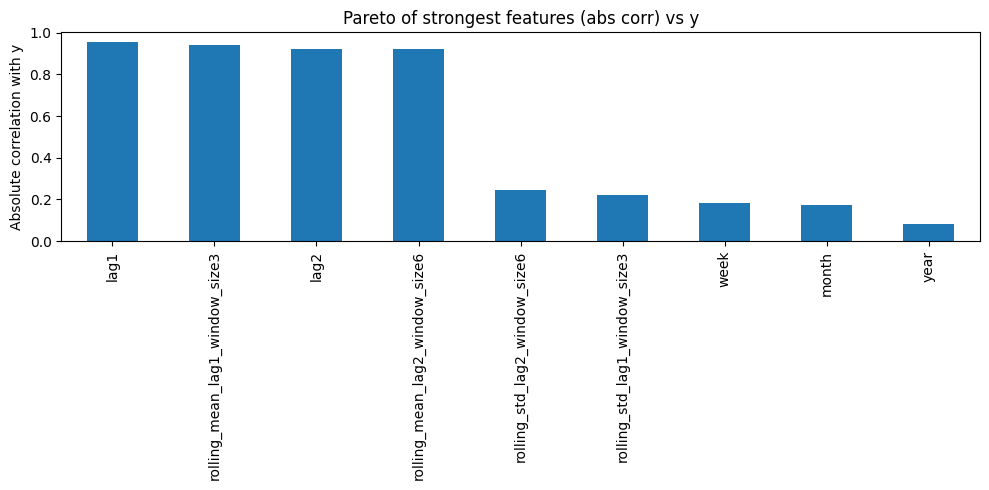

In [46]:
# Pareto plot
pareto = corr_abs.head(top_k).dropna()
cumul = pareto.cumsum() / pareto.sum()

fig, ax = plt.subplots(figsize=(10, 5))
pareto.plot(kind="bar", ax=ax)
ax.set_ylabel("Absolute correlation with y")
ax.set_title("Pareto of strongest features (abs corr) vs y")
plt.tight_layout()
plt.show()

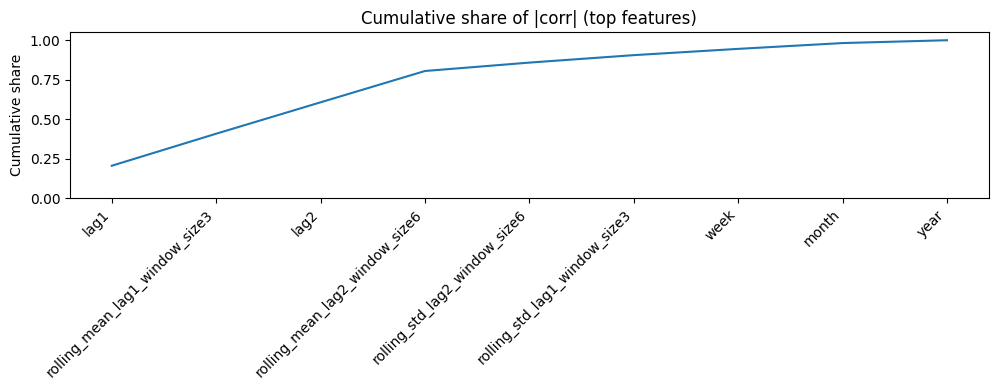

In [47]:
# Cumulative share plot
fig, ax = plt.subplots(figsize=(10, 4))
cumul.plot(ax=ax)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Cumulative share")
ax.set_xticks(range(len(cumul)))
ax.set_xticklabels(cumul.index, rotation=45, ha="right")
ax.set_title("Cumulative share of |corr| (top features)")
plt.tight_layout()
plt.show()

## Train XGBoost and Visualize Feature Importance

In [48]:
# Fix: ensure XGBoost receives only numeric features (run before training)
X = df_features[feature_cols].copy()

# Convert object/category columns safely to integer codes
for c in X.columns:
    if str(X[c].dtype) in ("object", "category", "bool"):
        X[c] = X[c].astype("category").cat.codes.astype("int32")

# Force numeric and clean invalid values
X = X.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)

# Align with target and drop rows with invalid feature values
valid_idx = X.notna().all(axis=1) & y_vec.notna()
X = X.loc[valid_idx]
y_vec = y_vec.loc[valid_idx]

print("✅ X fixed for XGBoost")
print("X shape:", X.shape)
print("y shape:", y_vec.shape)
print("Non-numeric columns left:", X.select_dtypes(exclude=[np.number]).columns.tolist())

✅ X fixed for XGBoost
X shape: (4800, 24)
y shape: (4800,)
Non-numeric columns left: []


In [49]:
xgb.fit(X, y_vec)
print("✅ XGBoost model trained successfully")

✅ XGBoost model trained successfully


In [50]:
# Display feature importance
importances = xgb.feature_importances_
fi = (pd.Series(importances, index=X.columns)
        .sort_values(ascending=False))

print("\nTop model importances:")
print(fi.head(20))


Top model importances:
profile_cluster                   0.430937
lag1                              0.306306
BASELINE_WEEKLY_SALES             0.153409
rolling_mean_lag1_window_size3    0.058875
week                              0.012642
month                             0.009827
STORE_SELLING_AREA_SQFT           0.009147
year                              0.002718
rolling_mean_lag2_window_size6    0.002482
lag2                              0.001880
rolling_std_lag2_window_size6     0.001505
rolling_std_lag1_window_size3     0.001468
STORE_ARCHETYPE                   0.001364
COMPETITOR_WAREHOUSE_A_PRESENT    0.000970
MARKET_SHARE_AREA_POSTAL          0.000865
REGION                            0.000857
COMPETITOR_DISCOUNT_A_PRESENT     0.000796
STORE_COUNT_IN_POSTAL_AREA        0.000785
NEARBY_COMPETITOR_STORE_COUNT     0.000690
COMPETITOR_DISCOUNT_B_PRESENT     0.000670
dtype: float32


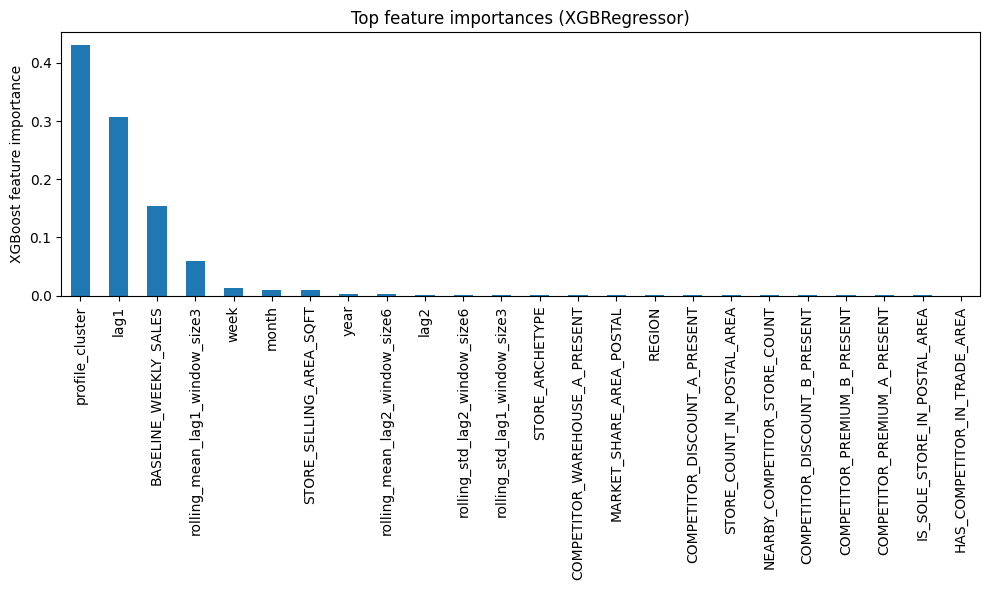

In [51]:
# Feature importance plot
fig, ax = plt.subplots(figsize=(10, 6))
fi.head(30).plot(kind="bar", ax=ax)
ax.set_ylabel("XGBoost feature importance")
ax.set_title("Top feature importances (XGBRegressor)")
plt.tight_layout()
plt.show()

# Feature Importance by Cluster

Train a separate XGBoost model per cluster and compare the top feature importances side by side.

## Build the MLForecast Object by Cluster

✅ MLForecast object created
Processing cluster: 1
df_features shape: (1440, 27)
✅ Categorical columns converted to codes
✅ Feature matrix X shape: (1440, 24)
✅ Target vector y shape: (1440,)
   Features: ['STORE_SELLING_AREA_SQFT', 'NEARBY_COMPETITOR_STORE_COUNT', 'COMPETITOR_PREMIUM_A_PRESENT', 'COMPETITOR_DISCOUNT_A_PRESENT', 'COMPETITOR_WAREHOUSE_A_PRESENT', 'COMPETITOR_PREMIUM_B_PRESENT', 'COMPETITOR_DISCOUNT_B_PRESENT', 'HAS_COMPETITOR_IN_TRADE_AREA', 'STORE_COUNT_IN_POSTAL_AREA', 'IS_SOLE_STORE_IN_POSTAL_AREA', 'MARKET_SHARE_AREA_POSTAL', 'BASELINE_WEEKLY_SALES', 'STORE_ARCHETYPE', 'REGION', 'profile_cluster', 'lag1', 'lag2', 'rolling_mean_lag1_window_size3', 'rolling_std_lag1_window_size3', 'rolling_mean_lag2_window_size6', 'rolling_std_lag2_window_size6', 'year', 'month', 'week']
Top correlations with y (absolute):
lag1                              0.903896
rolling_mean_lag1_window_size3    0.874460
lag2                              0.835197
rolling_mean_lag2_window_size6    0.

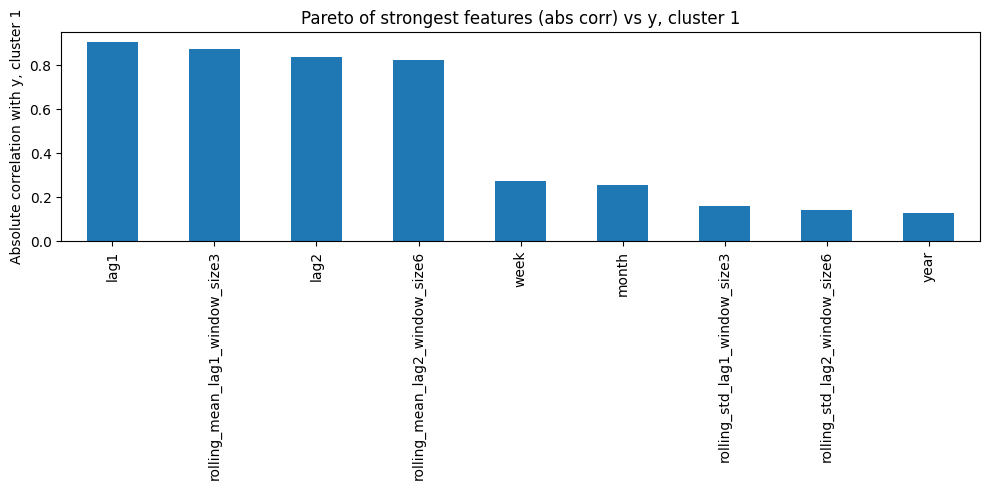

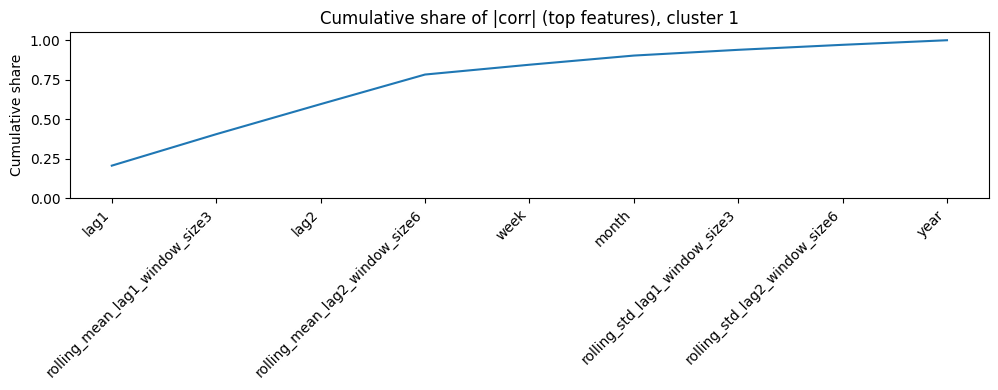

Processing cluster: 0
df_features shape: (3360, 27)
✅ Categorical columns converted to codes
✅ Feature matrix X shape: (3360, 24)
✅ Target vector y shape: (3360,)
   Features: ['STORE_SELLING_AREA_SQFT', 'NEARBY_COMPETITOR_STORE_COUNT', 'COMPETITOR_PREMIUM_A_PRESENT', 'COMPETITOR_DISCOUNT_A_PRESENT', 'COMPETITOR_WAREHOUSE_A_PRESENT', 'COMPETITOR_PREMIUM_B_PRESENT', 'COMPETITOR_DISCOUNT_B_PRESENT', 'HAS_COMPETITOR_IN_TRADE_AREA', 'STORE_COUNT_IN_POSTAL_AREA', 'IS_SOLE_STORE_IN_POSTAL_AREA', 'MARKET_SHARE_AREA_POSTAL', 'BASELINE_WEEKLY_SALES', 'STORE_ARCHETYPE', 'REGION', 'profile_cluster', 'lag1', 'lag2', 'rolling_mean_lag1_window_size3', 'rolling_std_lag1_window_size3', 'rolling_mean_lag2_window_size6', 'rolling_std_lag2_window_size6', 'year', 'month', 'week']
Top correlations with y (absolute):
lag1                              0.872537
rolling_mean_lag1_window_size3    0.839855
lag2                              0.791667
rolling_mean_lag2_window_size6    0.777178
week                 

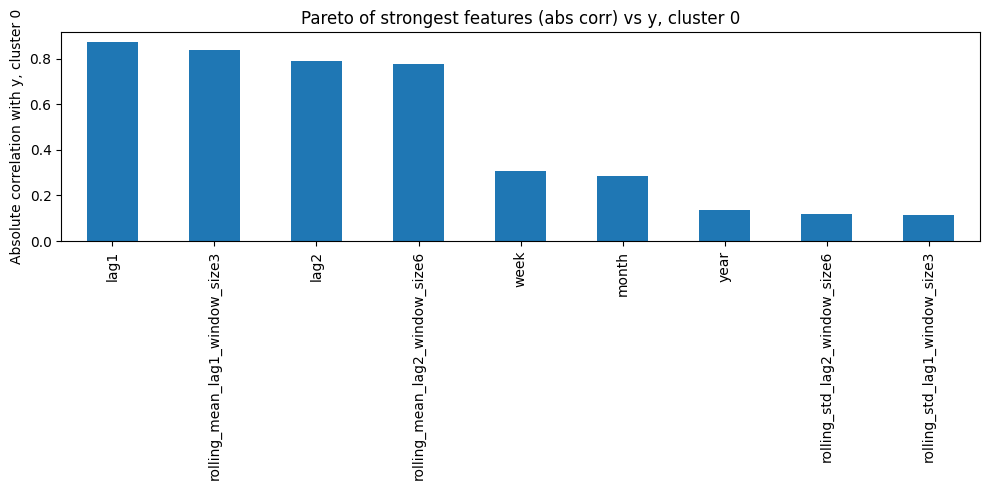

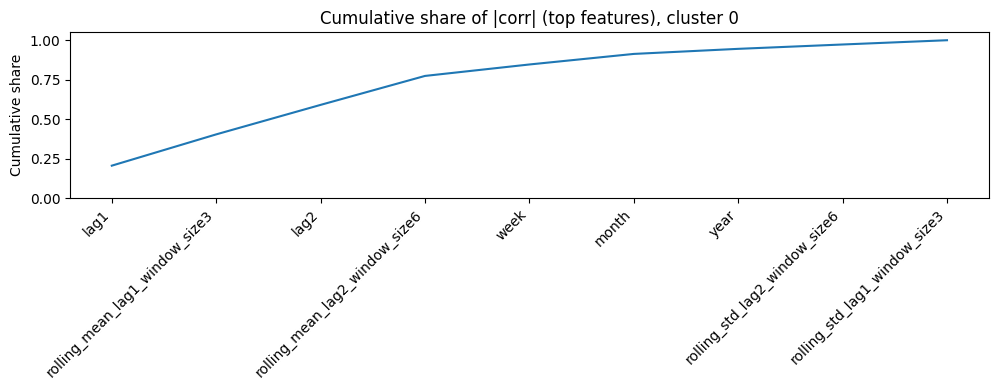

In [56]:
# Create MLForecast object for feature engineering by cluster
fcst_by_cluster = MLForecast(
    models={"xgb": xgb},     # named dict helps when inspecting multiple models later
    freq=FREQ,               # e.g., 'MS' for month-start
    lags=lags,
    lag_transforms=lag_transforms,
    date_features=date_features,
)
print("✅ MLForecast object created")

# Create a dictionary to hold features by cluster
dict_features = {}

for c in df['profile_cluster'].unique():
    print(f"Processing cluster: {c}")
    dict_features[c] = fcst_by_cluster.preprocess(
        df[df['profile_cluster'] == c][[unique_id, 'ds', y] + static_cols],
        id_col=unique_id,
        time_col='ds',
        target_col=y,
        static_features=static_cols,
        dropna=True,
        as_numpy=False,
    )

    print("df_features shape:", dict_features[c].shape)

    # Convert categorical columns to codes for modeling
    cat_cols_to_convert = [col for col in categorical_cols if col in dict_features[c].columns]
    for col in cat_cols_to_convert:
        dict_features[c][col] = dict_features[c][col].cat.codes.astype("int32")

    print("✅ Categorical columns converted to codes")
    
    # Build feature matrix and target vector for the cluster
    feature_cols = [col for col in dict_features[c].columns if col not in [unique_id, "ds", y]]
    X = dict_features[c][feature_cols].copy()
    y_vec = dict_features[c][y].copy()

    print(f"✅ Feature matrix X shape: {X.shape}")
    print(f"✅ Target vector y shape: {y_vec.shape}")
    print(f"   Features: {feature_cols}")
    
    # Compute correlations with target for the cluster
    corr = X.join(y_vec).corr(numeric_only=True)[y].drop(labels=[y])
    corr_abs = corr.abs().sort_values(ascending=False)

    # Show top-k correlations
    top_k = 20
    print("Top correlations with y (absolute):")
    print(corr_abs.head(top_k))
    
    # Pareto plot
    pareto = corr_abs.head(top_k).dropna()
    cumul = pareto.cumsum() / pareto.sum()

    fig, ax = plt.subplots(figsize=(10, 5))
    pareto.plot(kind="bar", ax=ax)
    ax.set_ylabel(f"Absolute correlation with y, cluster {c}")
    ax.set_title(f"Pareto of strongest features (abs corr) vs y, cluster {c}")
    plt.tight_layout()
    plt.show()
    
    # Cumulative share plot
    fig, ax = plt.subplots(figsize=(10, 4))
    cumul.plot(ax=ax)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Cumulative share")
    ax.set_xticks(range(len(cumul)))
    ax.set_xticklabels(cumul.index, rotation=45, ha="right")
    ax.set_title(f"Cumulative share of |corr| (top features), cluster {c}")
    plt.tight_layout()
    plt.show()
    

## Feature importance by cluster


--- Cluster 0 (3360 rows) — Top 20 features ---
lag1                              0.420933
BASELINE_WEEKLY_SALES             0.267152
rolling_mean_lag1_window_size3    0.083865
week                              0.068788
month                             0.057805
year                              0.017286
rolling_mean_lag2_window_size6    0.009991
lag2                              0.009576
rolling_std_lag1_window_size3     0.007927
rolling_std_lag2_window_size6     0.007628
STORE_SELLING_AREA_SQFT           0.005023
MARKET_SHARE_AREA_POSTAL          0.004747
REGION                            0.004676
STORE_COUNT_IN_POSTAL_AREA        0.004657
COMPETITOR_PREMIUM_A_PRESENT      0.004119
NEARBY_COMPETITOR_STORE_COUNT     0.004117
COMPETITOR_DISCOUNT_B_PRESENT     0.004037
COMPETITOR_PREMIUM_B_PRESENT      0.003794
COMPETITOR_WAREHOUSE_A_PRESENT    0.003788
IS_SOLE_STORE_IN_POSTAL_AREA      0.003672

--- Cluster 1 (1440 rows) — Top 20 features ---
BASELINE_WEEKLY_SALES             0.347136

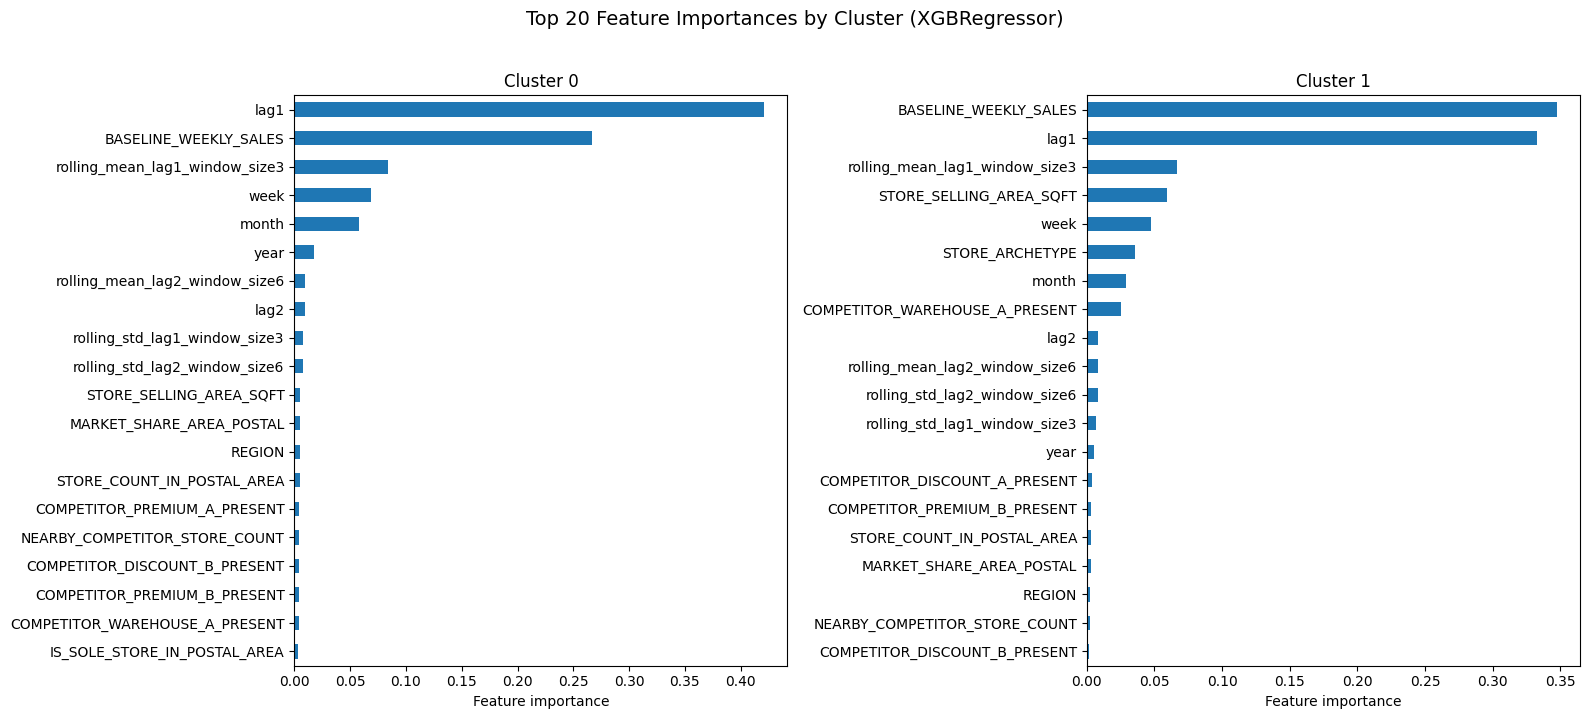

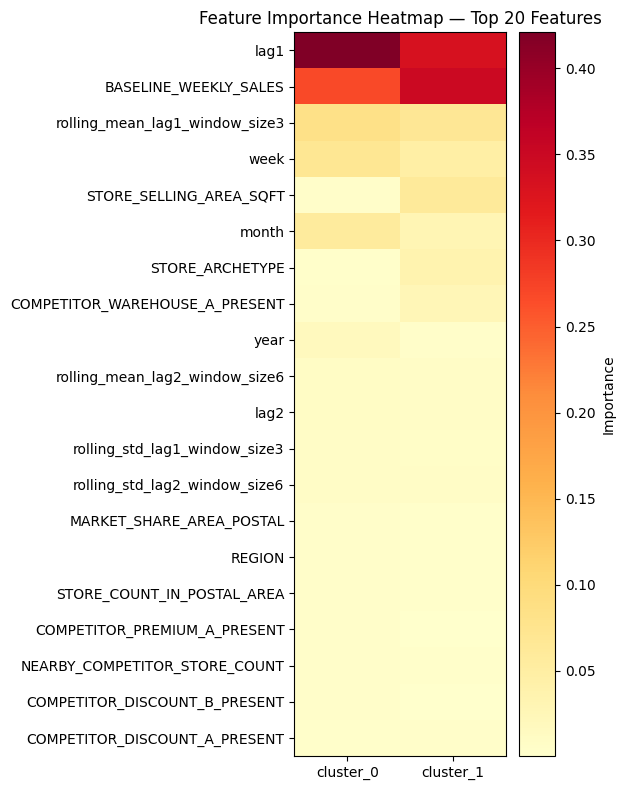

In [57]:
# --- Feature importance by cluster ---
cluster_col = 'profile_cluster'
clusters = sorted(df_features[cluster_col].dropna().unique())
top_n = 20

importance_by_cluster = {}

for cl in clusters:
    df_feature_by_cluster = dict_features[cl]
    mask = df_feature_by_cluster[cluster_col] == cl
    X_cl = df_feature_by_cluster.loc[mask, feature_cols].copy()
    y_cl = df_feature_by_cluster.loc[mask, y].copy()

    # Same preprocessing as the overall model
    for c in X_cl.columns:
        if str(X_cl[c].dtype) in ("object", "category", "bool"):
            X_cl[c] = X_cl[c].astype("category").cat.codes.astype("int32")
    X_cl = X_cl.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)

    valid = X_cl.notna().all(axis=1) & y_cl.notna()
    X_cl, y_cl = X_cl.loc[valid], y_cl.loc[valid]

    model_cl = XGBRegressor(
        n_estimators=500, max_depth=6, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9, random_state=42, n_jobs=-1,
    )
    model_cl.fit(X_cl, y_cl)

    fi_cl = pd.Series(model_cl.feature_importances_, index=X_cl.columns).sort_values(ascending=False)
    importance_by_cluster[cl] = fi_cl
    print(f"\n--- Cluster {cl} ({len(X_cl)} rows) — Top {top_n} features ---")
    print(fi_cl.head(top_n).to_string())

# --- Side-by-side chart ---
n_clusters = len(clusters)
fig, axes = plt.subplots(1, n_clusters, figsize=(8 * n_clusters, 7), sharey=False)
if n_clusters == 1:
    axes = [axes]

for ax, cl in zip(axes, clusters):
    fi_cl = importance_by_cluster[cl].head(top_n)
    fi_cl.plot(kind="barh", ax=ax)
    ax.set_xlabel("Feature importance")
    ax.set_title(f"Cluster {cl}")
    ax.invert_yaxis()

fig.suptitle(f"Top {top_n} Feature Importances by Cluster (XGBRegressor)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# --- Heatmap comparison ---
fi_df = pd.DataFrame(importance_by_cluster)
fi_df.columns = [f"cluster_{c}" for c in fi_df.columns]
# Keep only features that appear in any cluster's top-N
top_feats = fi_df.max(axis=1).sort_values(ascending=False).head(top_n).index
fi_top = fi_df.loc[top_feats]

fig, ax = plt.subplots(figsize=(6, 8))
im = ax.imshow(fi_top.values, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(fi_top.shape[1]))
ax.set_xticklabels(fi_top.columns)
ax.set_yticks(range(fi_top.shape[0]))
ax.set_yticklabels(fi_top.index)
fig.colorbar(im, ax=ax, label="Importance")
ax.set_title(f"Feature Importance Heatmap — Top {top_n} Features")
plt.tight_layout()
plt.show()

# Save Features to Lakehouse

In [58]:
# Save df_features to Lakehouse
try:
    spark_df_features = spark.createDataFrame(df_features)
    spark_df_features.write.mode("overwrite").saveAsTable(f"{LAKEHOUSE_NAME}.{OUTPUT_TABLE}")
    print(f"✅ df_features saved to lakehouse table: {LAKEHOUSE_NAME}.{OUTPUT_TABLE}")
except Exception as e:
    print(f"❌ Error saving df_features to Lakehouse: {e}")
    print("Saving to local file instead.")
    df_features.to_parquet(f"{root_path}/data/{OUTPUT_TABLE}.parquet", index=False)
    print(f"✅ df_features saved locally at: {root_path}/data/{OUTPUT_TABLE}.parquet")  


❌ Error saving df_features to Lakehouse: name 'spark' is not defined
Saving to local file instead.
✅ df_features saved locally at: c:\Users\mabellani\OneDrive - Microsoft\Documents\REPOSITORY\time-series-forecasting-accelerator/data/df_features.parquet


In [59]:
# Create a separate DataFrame for each cluster
for cl in clusters:
    df_cl = dict_features[cl].copy()
    var_name = f"df_features_cluster_{cl}"
    globals()[var_name] = df_cl
    print(f"✅ {var_name}: {df_cl.shape}")
    
    # Save to Lakehouse (or local fallback)
    table_name = f"{OUTPUT_TABLE}_cluster_{cl}"
    try:
        spark_cl = spark.createDataFrame(df_cl)
        spark_cl.write.mode("overwrite").saveAsTable(f"{LAKEHOUSE_NAME}.{table_name}")
        print(f"   Saved to lakehouse: {LAKEHOUSE_NAME}.{table_name}")
    except Exception as e:
        local_path = f"{root_path}/data/{table_name}.parquet"
        df_cl.to_parquet(local_path, index=False)
        print(f"   Saved locally: {local_path}")

✅ df_features_cluster_0: (3360, 27)
   Saved locally: c:\Users\mabellani\OneDrive - Microsoft\Documents\REPOSITORY\time-series-forecasting-accelerator/data/df_features_cluster_0.parquet
✅ df_features_cluster_1: (1440, 27)
   Saved locally: c:\Users\mabellani\OneDrive - Microsoft\Documents\REPOSITORY\time-series-forecasting-accelerator/data/df_features_cluster_1.parquet


In [60]:
df_features_cluster_0.columns

Index(['STORE_LOCATION_ID', 'ds', 'TOTAL_NET_SALES', 'STORE_SELLING_AREA_SQFT',
       'NEARBY_COMPETITOR_STORE_COUNT', 'COMPETITOR_PREMIUM_A_PRESENT',
       'COMPETITOR_DISCOUNT_A_PRESENT', 'COMPETITOR_WAREHOUSE_A_PRESENT',
       'COMPETITOR_PREMIUM_B_PRESENT', 'COMPETITOR_DISCOUNT_B_PRESENT',
       'HAS_COMPETITOR_IN_TRADE_AREA', 'STORE_COUNT_IN_POSTAL_AREA',
       'IS_SOLE_STORE_IN_POSTAL_AREA', 'MARKET_SHARE_AREA_POSTAL',
       'BASELINE_WEEKLY_SALES', 'STORE_ARCHETYPE', 'REGION', 'profile_cluster',
       'lag1', 'lag2', 'rolling_mean_lag1_window_size3',
       'rolling_std_lag1_window_size3', 'rolling_mean_lag2_window_size6',
       'rolling_std_lag2_window_size6', 'year', 'month', 'week'],
      dtype='object')

In [61]:
df_features_cluster_1.columns

Index(['STORE_LOCATION_ID', 'ds', 'TOTAL_NET_SALES', 'STORE_SELLING_AREA_SQFT',
       'NEARBY_COMPETITOR_STORE_COUNT', 'COMPETITOR_PREMIUM_A_PRESENT',
       'COMPETITOR_DISCOUNT_A_PRESENT', 'COMPETITOR_WAREHOUSE_A_PRESENT',
       'COMPETITOR_PREMIUM_B_PRESENT', 'COMPETITOR_DISCOUNT_B_PRESENT',
       'HAS_COMPETITOR_IN_TRADE_AREA', 'STORE_COUNT_IN_POSTAL_AREA',
       'IS_SOLE_STORE_IN_POSTAL_AREA', 'MARKET_SHARE_AREA_POSTAL',
       'BASELINE_WEEKLY_SALES', 'STORE_ARCHETYPE', 'REGION', 'profile_cluster',
       'lag1', 'lag2', 'rolling_mean_lag1_window_size3',
       'rolling_std_lag1_window_size3', 'rolling_mean_lag2_window_size6',
       'rolling_std_lag2_window_size6', 'year', 'month', 'week'],
      dtype='object')